# Lab 5.1: Convolutions

In this lab you will see how the 2D cross-correlation filter can act as a simple pattern recognizer or object detector.

In [9]:
from urllib.request import urlretrieve

url = "https://www.dropbox.com/scl/fi/vc3j08yctlosvpr57v2ot/cat.jpg?rlkey=nbgc9klg8wlgkfewk08ln72xf&dl=1"
urlretrieve(url, "cat.jpg")

('cat.jpg', <http.client.HTTPMessage at 0x1939b8f3230>)

In [10]:
from imageio.v3 import imread, imwrite
from skimage.transform import rescale
from scipy.ndimage import convolve, correlate
from skimage.color import rgb2gray
from matplotlib import pyplot as plt
import numpy as np

### Exercises

1. Load the `cat.jpg` image, rescale it by 50%, and convert to grayscale as done in Notebook 5.1.

In [12]:
# YOUR CODE GOES HERE
img = imread("cat.jpg")

rescaled_img = rescale(
    img,
    0.5,
    anti_aliasing=True,
    channel_axis=-1
)

greyscale_img = rgb2gray(rescaled_img)

2. These coordinates specify a box around the cat's face:

- Top, Left: (0,205)
- Bottom, Right: (128,325)

Crop the `gray` image to this box and show the result.  It should show just the cat's face.

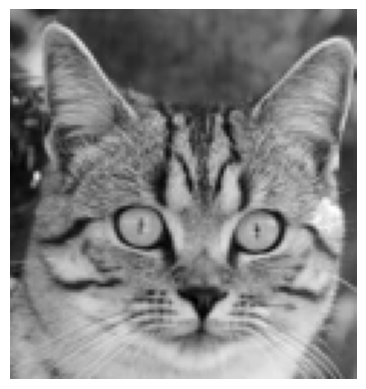

In [15]:
# YOUR CODE GOES HERE
face_crop = greyscale_img[0:128, 205:325]

plt.imshow(face_crop, cmap="gray")
plt.axis("off")
plt.show()

3. To turn the cat face into a filter, subtract the mean from the cropped image.

Print out the mean of the filter to verify that it is zero.

In [17]:
# YOUR CODE GOES HERE
cat_filter = face_crop - np.mean(face_crop)

print(np.mean(cat_filter))

1.4802973661668754e-17


4. Apply the cat face filter to the original `gray` image using cross-correlation and show the result.

You should see a bright spot at the location of middle of the cat's face.  Why?

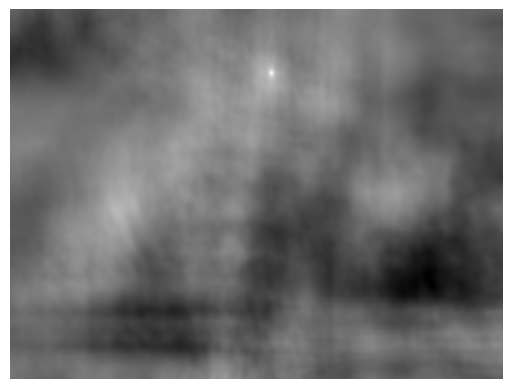

In [18]:
# YOUR CODE GOES HERE
correlation_result = correlate(greyscale_img, cat_filter)

plt.imshow(correlation_result, cmap="gray")
plt.axis("off")
plt.show()

The bright spot appears beucase that region most closely matches the cat_filter. Cross correlation produces a large value wehere the image pattern and filter pattern align.

5. Now let's crop one of the eyes and see how that well that works as an eye detector.

The left eye's coordinates:
- Top, Left: 68, 241
- Bottom, Right: 82, 259

Crop out the left eye, convert to a filter, and show the result of cross-correlation.

Does it detect both eyes well, or just the left eye?

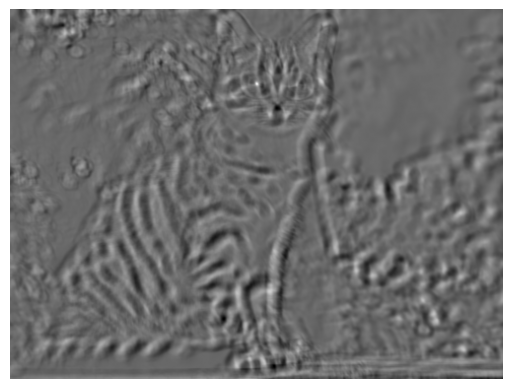

In [19]:
# YOUR CODE GOES HERE
eye = greyscale_img[68:82, 241:259]

eye_filter = eye - np.mean(eye)

correlation_result = correlate(greyscale_img, eye_filter)
plt.imshow(correlation_result, cmap="gray")
plt.axis("off")
plt.show()


The filter detects the left eye, but the right eye less effectively. Since the eyes have different oreientations and surrounding pixel patterns, the left eye matches the template where the right eye dosent match as well.

6. To improve the result of the eye detector, we can crop both eyes and average them together before creating the filter.

Here are the right eye coordinates:
- Top, Left: 70, 282
- Bottom, Right: 84, 300

Crop out the right eye, compute the average of the left eye and right eye crops, and then create the filter from that and show the result.

Does the averaged eye filter detect both eyes more effectively than the left eye filter?  Why?

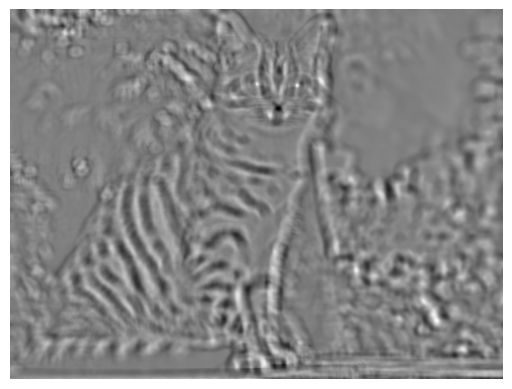

In [20]:
# YOUR CODE GOES HERE

right_eye = greyscale_img[70:84, 282:300]

average_eye = (eye + right_eye) / 2

average_eye_filter = average_eye - np.mean(average_eye)

average_eye_result = correlate(greyscale_img, average_eye_filter)
plt.imshow(average_eye_result, cmap="gray")
plt.axis("off")
plt.show()


The average filter detects both eyes more effectively beucase it captures the features shared by both eyes while reducing details unique to just one eye.